In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import tensorflow as tf
print(tf.keras.__version__)

3.13.2


FruitinAmazon dataset is a collection of images specifically curated to represent various types of fruits (like Apples, Bananas, Oranges, etc.).

In [3]:
import zipfile, os

ZIP_PATH = "/content/drive/MyDrive/Colab Notebooks/AI_ML_Practice/Week5/FruitinAmazon.zip" # location of my zipfile

EXTRACT_DIR = "./fruitnamazon_dataset" # under current directory (./) create the new folder to store extracted dataset
os.makedirs(EXTRACT_DIR, exist_ok=True) # this is where it actually gets created.

# Unzip the file
with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
    zip_ref.extractall(EXTRACT_DIR)
print(f"File '{os.path.basename(ZIP_PATH)}' unzipped to '{EXTRACT_DIR}'")

File 'FruitinAmazon.zip' unzipped to './fruitnamazon_dataset'


##Task 1: Data Understanding and Visualization:

1. Load and visualize images from a dataset stored in directories, where each subdirec-
tory represents a class.

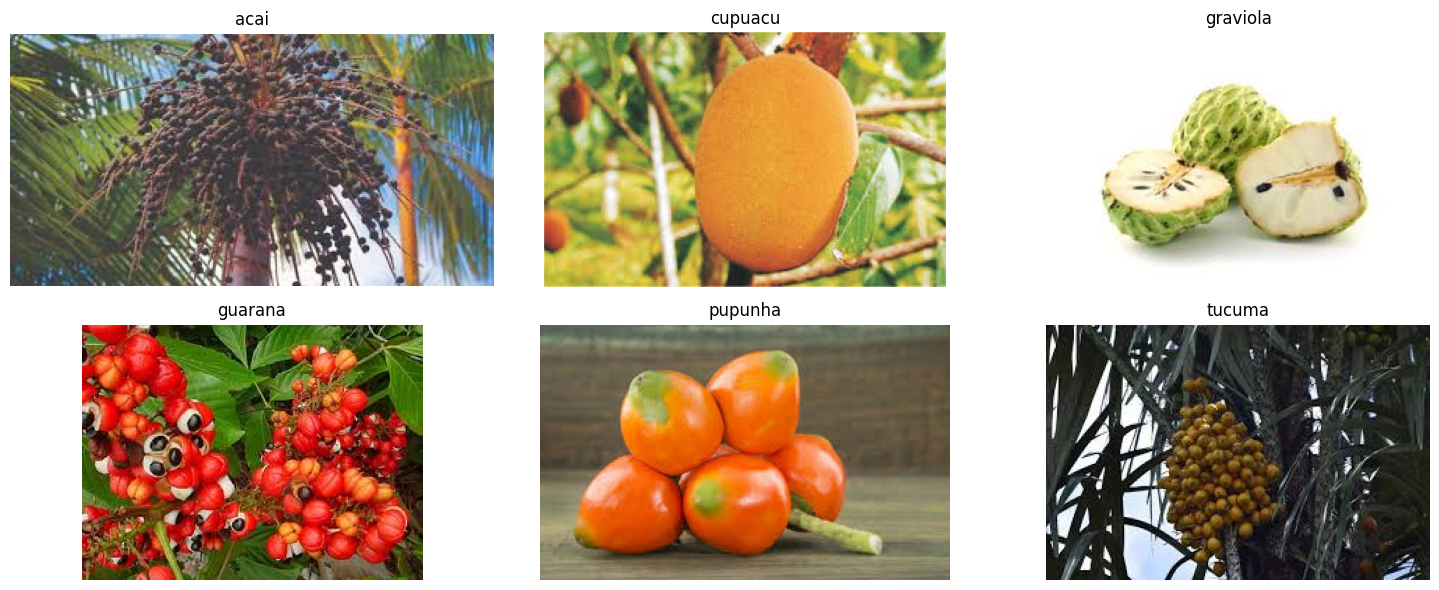

In [4]:
import os
import random
import matplotlib.pyplot as plt
from PIL import Image

# training data path
train_dir = "/content/fruitnamazon_dataset/FruitinAmazon/train"

# finds list of folder and each folder is class, folder: apple, banana, orange etc.
class_names = sorted([d for d in os.listdir(train_dir) if os.path.isdir(os.path.join(train_dir, d))])

# calculates how many columns we need to fit all classes into exactly 2 rows
num_classes = len(class_names)
cols = (num_classes + 1) // 2  # Calculate columns needed for 2 rows
plt.figure(figsize=(15, 6))

# Random Selection Loop and plots
for i, class_name in enumerate(class_names):
    class_path = os.path.join(train_dir, class_name)
    random_img_name = random.choice(os.listdir(class_path))
    img_path = os.path.join(class_path, random_img_name)

    img = Image.open(img_path)

    plt.subplot(2, cols, i + 1)
    plt.imshow(img)
    plt.title(class_name)
    plt.axis("off")

plt.tight_layout()
plt.show()

Check for Corrupted Image:

In [5]:

corrupted_images = []

# Iterate through each class subdirectory
for class_name in class_names:
    class_path = os.path.join(train_dir, class_name)

    for filename in os.listdir(class_path):
        image_path = os.path.join(class_path, filename)

        try:
            # Attempt to load and verify the image
            with Image.open(image_path) as img:
                img.verify()
        except (IOError, SyntaxError):
            # If corrupted, remove and record
            print(f"Removed corrupted image: {image_path}")
            os.remove(image_path)
            corrupted_images.append(image_path)


if not corrupted_images:
    print("No Corrupted Images Found.")
else:
    print(f"Cleaned up {len(corrupted_images)} images.")

No Corrupted Images Found.


##Task 2: Loading and Preprocessing Image Data in keras:

In [6]:
img_height = 128 # Example image height
img_width = 128 # Example image width
batch_size = 32
validation_split = 0.2 # 80% training, 20% validation

#Pixel values are 0–255, dividing by 255 brings them to 0–1.
rescale = tf.keras.layers.Rescaling(1./255)

# 3. Create training dataset
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',     #tells label to use subfolder names
    label_mode='int', #Encode labels as integers — apple=0, banana=1, mango=2 etc. Required for sparse_categorical_crossentropy.
    image_size=(img_height, img_width),
    interpolation='nearest', #When resizing, fill new pixels by copying the nearest original pixel. Simple and fast.
    batch_size=batch_size,
    shuffle=True, #Randomise order every epoch so the model doesn't learn class order instead of patterns.
    validation_split=validation_split,
    subset='training', #This call gets the 80% training portion. The val_ds call below gets the other 20%
    seed=123 #guarantes the same 80/20 split every time, no image appears in both.
)

# 4. Create validation dataset
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    interpolation='nearest',
    batch_size=batch_size,
    shuffle=False,              # Validation should not be shuffled
    validation_split=validation_split,
    subset='validation',
    seed=123
)

# 5. Apply Normalization to both
train_ds = train_ds.map(lambda x, y: (rescale(x), y))
val_ds = val_ds.map(lambda x, y: (rescale(x), y))

print("\nDatasets are loaded and normalized!")

Found 90 files belonging to 6 classes.
Using 72 files for training.
Found 90 files belonging to 6 classes.
Using 18 files for validation.

Datasets are loaded and normalized!


In [9]:
from tensorflow.keras import layers, models

#  lists everything inside the train folder
#  filters to folders only
class_names = sorted([d for d in os.listdir(train_dir) if os.path.isdir(os.path.join(train_dir, d))])
num_classes = len(class_names)

print(f"Building model for {num_classes} classes: {class_names}\n")

# Build the Sequential Model
model = models.Sequential([
    # --- Convolutional Architecture ---

    # Convolutional Layer 1
    # create 32 filters, producing 32 feature maps. Each filter learns a different pattern — edges, curves,
    # each filter is a 3×3 grid of learnable numbers sliding across the image.
    # move the filter one pixel at a time horizontally and vertically.
    # adds zeros around the border so output spatial size = input spatial size
    layers.Conv2D(filters=32, kernel_size=(3, 3), strides=(1, 1),
                  padding='same', activation='relu', input_shape=(128, 128, 3)),

    #window that slides across the feature map taking the maximum value from each 2×2 region.
    # jumps 2 pixels each time, so windows don't overlap. This is what halves the spatial size.
    layers.MaxPooling2D(pool_size=(2, 2), strides=(2, 2)),

    # Convolutional Layer 2
    layers.Conv2D(filters=32, kernel_size=(3, 3), strides=(1, 1),
                  padding='same', activation='relu'),
    layers.MaxPooling2D(pool_size=(2, 2), strides=(2, 2)),

    # --- Fully Connected Network Architecture ---
    layers.Flatten(),

    # Hidden Layer 1 (64 neurons)
    layers.Dense(64, activation='relu'),

    # Hidden Layer 2 (128 neurons)
    layers.Dense(128, activation='relu'),

    # Output Layer
    # one neuron per fruit class.
    layers.Dense(num_classes, activation='softmax')
])

model.summary()

Building model for 6 classes: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']



Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │     2,097,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,116,454 (8.07 MB)

 Trainable params: 2,116,454 (8.07 MB)

 Non-trainable params: 0 (0.00 B)

Task 4: Compile and Train the Model

In [10]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint


model.compile(
    optimizer='adam', #tells Keras how to update weights during backward propagation. Adam automatically adapts the learning rate η per weight
    loss='sparse_categorical_crossentropy', #  labels are integers
    metrics=['accuracy']
)


# ModelCheckpoint saves the best version based on validation loss
checkpoint = ModelCheckpoint(
    'best_fruit_model.h5',
    monitor='val_loss', # Watch validation loss, not training loss.
    save_best_only=True, #Only overwrite best_fruit_model.h5 when val_loss improves. Without this, every epoch overwrites the file
    verbose=1 # Print a message when the model is saved
)

# EarlyStopping stops training if val_loss doesn't improve for 10 epochs
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)


history = model.fit(
    train_ds,
    epochs=250,
    validation_data=val_ds,
    callbacks=[checkpoint, early_stop]
)



Epoch 1/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 553ms/step - accuracy: 0.2153 - loss: 2.0794
Epoch 1: val_loss improved from None to 1.52468, saving model to best_fruit_model.h5



Epoch 1: finished saving model to best_fruit_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 923ms/step - accuracy: 0.2083 - loss: 2.2335 - val_accuracy: 0.1667 - val_loss: 1.5247
Epoch 2/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 593ms/step - accuracy: 0.1997 - loss: 2.0297
Epoch 2: val_loss did not improve from 1.52468
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 780ms/step - accuracy: 0.2083 - loss: 1.9985 - val_accuracy: 0.4444 - val_loss: 1.5387
Epoch 3/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 320ms/step - accuracy: 0.4352 - loss: 1.6085
Epoch 3: val_loss improved from 1.52468 to 1.38002, saving model to best_fruit_model.h5



Epoch 3: finished saving model to best_fruit_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 437ms/step - accuracy: 0.4306 - loss: 1.5818 - val_accuracy: 0.3333 - val_loss: 1.3800
Epoch 4/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 342ms/step - accuracy: 0.4942 - loss: 1.4432
Epoch 4: val_loss did not improve from 1.38002
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 436ms/step - accuracy: 0.5139 - loss: 1.4293 - val_accuracy: 0.1667 - val_loss: 1.5148
Epoch 5/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 358ms/step - accuracy: 0.4340 - loss: 1.3290
Epoch 5: val_loss improved from 1.38002 to 1.16600, saving model to best_fruit_model.h5



Epoch 5: finished saving model to best_fruit_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 502ms/step - accuracy: 0.4583 - loss: 1.2835 - val_accuracy: 0.7222 - val_loss: 1.1660
Epoch 6/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 338ms/step - accuracy: 0.8113 - loss: 1.0288
Epoch 6: val_loss improved from 1.16600 to 0.74257, saving model to best_fruit_model.h5



Epoch 6: finished saving model to best_fruit_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 471ms/step - accuracy: 0.7778 - loss: 1.0781 - val_accuracy: 0.8889 - val_loss: 0.7426
Epoch 7/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 313ms/step - accuracy: 0.8038 - loss: 0.8691
Epoch 7: val_loss did not improve from 0.74257
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 401ms/step - accuracy: 0.8333 - loss: 0.8468 - val_accuracy: 0.6667 - val_loss: 1.0501
Epoch 8/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 337ms/step - accuracy: 0.8947 - loss: 0.7122
Epoch 8: val_loss improved from 0.74257 to 0.48532, saving model to best_fruit_model.h5



Epoch 8: finished saving model to best_fruit_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 449ms/step - accuracy: 0.9028 - loss: 0.6552 - val_accuracy: 0.8889 - val_loss: 0.4853
Epoch 9/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 395ms/step - accuracy: 0.8652 - loss: 0.5048
Epoch 9: val_loss did not improve from 0.48532
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 504ms/step - accuracy: 0.8611 - loss: 0.5196 - val_accuracy: 0.7778 - val_loss: 0.6035
Epoch 10/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 573ms/step - accuracy: 0.9103 - loss: 0.3705
Epoch 10: val_loss did not improve from 0.48532
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 680ms/step - accuracy: 0.9028 - loss: 0.3730 - val_accuracy: 0.8333 - val_loss: 0.5292
Epoch 11/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 335ms/step - accuracy: 0.9751 - loss: 0.2289
Epoch 11: val_loss improved from 0.48532 to 0.31925, saving model to best_fruit_model.h5



Epoch 11: finished saving model to best_fruit_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 449ms/step - accuracy: 0.9722 - loss: 0.2287 - val_accuracy: 0.8889 - val_loss: 0.3193
Epoch 12/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 329ms/step - accuracy: 0.9248 - loss: 0.2015
Epoch 12: val_loss did not improve from 0.31925
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 419ms/step - accuracy: 0.9306 - loss: 0.2067 - val_accuracy: 0.8333 - val_loss: 0.4312
Epoch 13/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 329ms/step - accuracy: 0.9502 - loss: 0.1385
Epoch 13: val_loss did not improve from 0.31925
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 419ms/step - accuracy: 0.9444 - loss: 0.1620 - val_accuracy: 0.8333 - val_loss: 0.5897
Epoch 14/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 327ms/step - accuracy: 0.9954 - loss: 0.1095
Epoch 14: val_loss did not improve from 0.31925
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 416ms/step - accuracy: 0.9861 - loss: 0.1056 - val_accuracy: 0.5556 - val_loss: 1.2053
Epoch 15/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 313ms/step - accuracy: 0.9300 - loss: 0.2

Task 5: Evaluate the Model

In [11]:
# --- Task 5: Evaluate the Model ---
print("\n--- Final Evaluation on Validation Set ---")
val_loss, val_accuracy = model.evaluate(val_ds)
print(f"Loss: {val_loss:.4f}, Accuracy: {val_accuracy:.4f}")


--- Final Evaluation on Validation Set ---
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step - accuracy: 0.8889 - loss: 0.3193
Loss: 0.3193, Accuracy: 0.8889


Task 6: Save and Load the Model

In [12]:
from tensorflow.keras.models import load_model

# 1. Save the model explicitly
model.save('final_fruit_model.h5')
print("Model saved successfully as 'final_fruit_model.h5'")

# 2. Load the saved model (using the 'best' one saved by our checkpoint)
loaded_model = load_model('best_fruit_model.h5')
print("Best version of the model reloaded successfully!")

# 3. Re-evaluate to prove it works
re_loss, re_acc = loaded_model.evaluate(val_ds)
print(f"Reloaded Model Accuracy: {re_acc*100:.2f}%")

Model saved successfully as 'final_fruit_model.h5'
Best version of the model reloaded successfully!
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 430ms/step - accuracy: 0.8889 - loss: 0.3193
Reloaded Model Accuracy: 88.89%


Task 7: Predictions and Classification Report

In [13]:
from sklearn.metrics import classification_report
import numpy as np

# 1. Extract ground truth and predictions
y_true = []
y_pred_probs = []

#Loops through val_ds batch by batch. Each iteration gives you one batch
print("Generating predictions...")
for images, labels in val_ds:
    preds = model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred_probs.extend(preds)

y_pred = np.argmax(y_pred_probs, axis=1)

# 2. Fix the naming mismatch
# Find which unique class indices are actually in y_true
present_classes_idx = np.unique(y_true)
# Filter class_names to only include those that appeared in the validation set
present_class_names = [class_names[i] for i in present_classes_idx]

# 3. Generate Report
# We pass 'labels' to tell the report exactly which IDs we are reporting on
report = classification_report(
    y_true,
    y_pred,
    labels=present_classes_idx,
    target_names=present_class_names
)

print("\n--- FINAL CLASSIFICATION REPORT ---")
print(report)

Generating predictions...

--- FINAL CLASSIFICATION REPORT ---
              precision    recall  f1-score   support

     pupunha       1.00      0.67      0.80         3
      tucuma       0.93      0.93      0.93        15

   micro avg       0.94      0.89      0.91        18
   macro avg       0.97      0.80      0.87        18
weighted avg       0.94      0.89      0.91        18



Precision — of everything the model called "pupunha", how many actually were? 1.00 = every pupunha prediction was correct, zero false alarms.

Recall — of all actual pupunha images, how many did the model find? 0.67 = it missed 1 out of 3 real pupunha images, labelling it as something else.

F1-score — harmonic mean of precision and recall. Single number summarising both. 0.80 for pupunha, 0.93 for tucuma.

Support — how many validation images exist per class. Pupunha only has 3 — this is why its metrics are unreliable. With 3 images, missing one drops recall by 33% instantly.